# Exercícios KNN

##  Exercício de Fixação 1.1

### Função do KNN

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def myknn(xt, xall, yall, k):

    dist = np.sum((xall - xt)**2, axis=1) # Quadrado da distância euclidiana
    
    idx = np.argsort(dist)[:k] # Índices dos k vizinhos mais próximos
    
    yhat = np.sign(np.sum(yall[idx]))
    
    return yhat if yhat != 0 else 1 # Em caso de empate, classificar como 1

Text(0.5, 1.0, 'Conjunto de Dados - Moons')

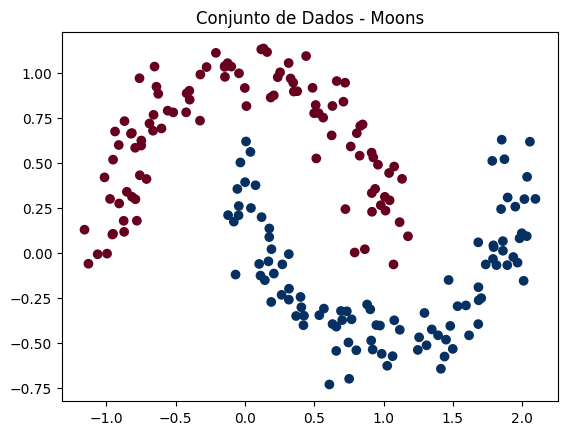

In [67]:
from sklearn import datasets
import matplotlib.pyplot as plt

X, y = datasets.make_moons(n_samples=200, noise=0.1, random_state=None)
y = np.where(y == 0, -1, 1) # Converter rótulos para -1 e 1
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu')
plt.title('Conjunto de Dados - Moons')

In [68]:
# 2. Sua função de plotagem corrigida
def plot_decision_boundary(X, y, k):
    # Margens para o gráfico
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Criação do grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
                         np.arange(y_min, y_max, 0.1))
    
    # Criamos uma matriz com todos os pontos do grid (N_pontos x 2)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # CORREÇÃO: Usamos xi_yi para não sobrescrever o nosso 'y' das classes
    Z = np.array([myknn(xi_yi, X, y, k) for xi_yi in grid_points])
    Z = Z.reshape(xx.shape)
    
    # Visualização
    plt.figure(figsize=(10, 8))
    # 'coolwarm' ou 'RdBu' costumam separar melhor o vermelho do azul visualmente
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', s=40)
    
    plt.title(f'Fronteira de Decisão KNN (k={k})')
    plt.xlabel('Eixo X1')
    plt.ylabel('Eixo X2')
    plt.grid(alpha=0.2)
    plt.show()



## Avaliação do método

O procedimento de avaliação seguirá da seguinte forma:

1. Gerar 4 conjuntos sintéticos da mesma distribuição com o mesmo tamanho.

2. Avaliar a fronteira de decisão pra K = 5, 10, 30, 50 e 100 nos 4 conjuntos diferentes.

In [69]:
# Gerar 4 conjuntos sintéticos da mesma distribuição (moons)
n_samples = 200
datasets_list = []

for i in range(4):
    X, y = datasets.make_moons(n_samples=n_samples, noise=0.2, random_state=i)
    y = np.where(y == 0, -1, 1)
    datasets_list.append((X, y, f'Dataset {i+1}'))

print(f"Gerados {len(datasets_list)} conjuntos sintéticos")
print(f"Tamanho de cada conjunto: {datasets_list[0][0].shape[0]} amostras")


Gerados 4 conjuntos sintéticos
Tamanho de cada conjunto: 200 amostras


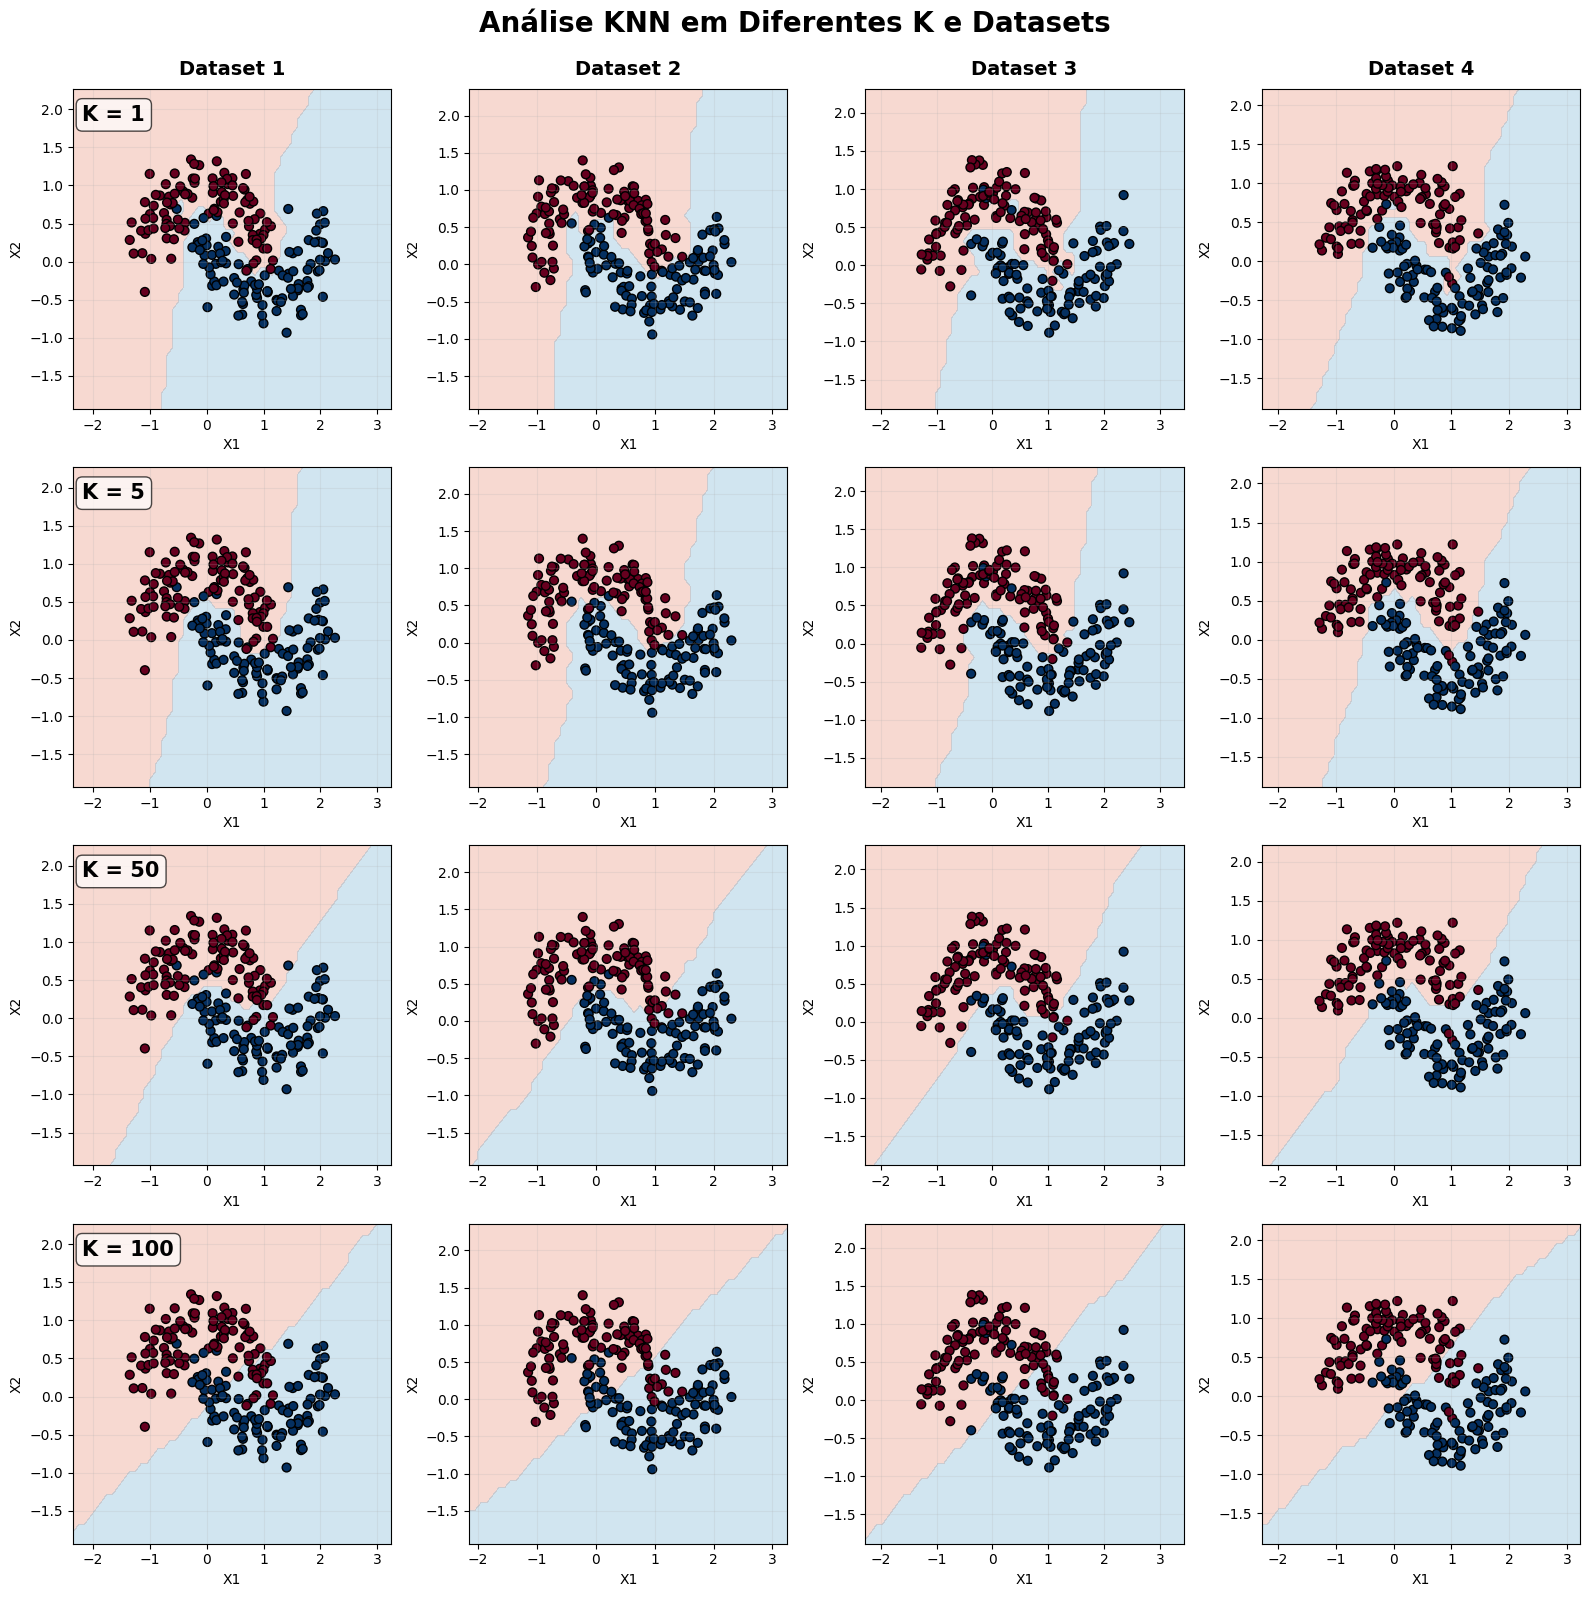

In [70]:
# Valores de K a serem testados
k_values = [1, 5, 50, 100]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Análise KNN em Diferentes K e Datasets', 
             fontsize=20, fontweight='bold', y=0.995)

# Para cada linha (K) e coluna (dataset)
for row, k in enumerate(k_values):
    for col, (X, y, label) in enumerate(datasets_list):
        ax = axes[row, col]
        
        # Criar o grid de pontos
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
                             np.arange(y_min, y_max, 0.1))
        
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Classificar cada ponto do grid
        Z = np.array([myknn(xi_yi, X, y, k) for xi_yi in grid_points])
        Z = Z.reshape(xx.shape)
        
        # Plotar
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=1)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', s=40)
        
        # Títulos: mostrar K na primeira coluna, Dataset na primeira linha
        if col == 0:
            # Adicionar texto dentro do subplot para K
            ax.text(0.03, 0.95, f'K = {k}', transform=ax.transAxes,
                   fontsize=15, fontweight='bold', color='black',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
                   verticalalignment='top')
        if row == 0:
            ax.set_title(label, fontsize=14, fontweight='bold', pad=10)
        
        ax.set_xlabel('X1', fontsize=10)
        ax.set_ylabel('X2', fontsize=10)
        ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Discussão

O dilema entre viés e variância reflete o tradeoff entre a sensibilidade do modelo aos detalhes e sua capacidade de generalização. No experimento, observou-se que com $k=1$, o modelo apresentou alta variância, gerando fronteiras irregulares e sensíveis a ruídos, o que caracteriza o overfitting. Por outro lado, com $k=100$, o cenário inverteu-se: a fronteira tornou-se excessivamente rígida, demonstrando um alto viés que ignora o comportamento real dos dados, resultando em underfitting. Na prática, o modelo transitou de um ajuste ao ruído para uma total incapacidade de aprender o padrão apresentado.

## Exercício de Fixação 1.2

Pelo enunciado, temos que:

$$\hat{y} = sinal(\sum_{i=1}^N y_i*\alpha_i*K(x,x_i))$$

$$K(x,x_i) \propto e^{\frac{1}{h}\sum_{j = 1}^n(x_j-x_{i,j})^2}$$

In [71]:
import numpy as np

def mykernel_knn(xt, xall, yall, h, k):
    # d^2 (distância euclidiana ao quadrado)
    dist_sq = np.sum((xall - xt)**2, axis=1)
    
    # Seleção dos k vizinhos
    idx = np.argsort(dist_sq)[:k]
    
    # d = 2 (dimensão dos dados X1 e X2)
    # A constante para d=2 simplifica para 1 / (2 * pi * h)
    dim = 2
    constante = 1 / ((2 * np.pi * h) ** (dim / 2))
    
    # Cálculo dos pesos com a constante incluída
    pesos = constante * np.exp(-0.5 * dist_sq[idx] / h)
    
    # Classificação por sinal (assumindo rótulos -1 e 1)
    return np.sign(np.sum(yall[idx] * pesos))

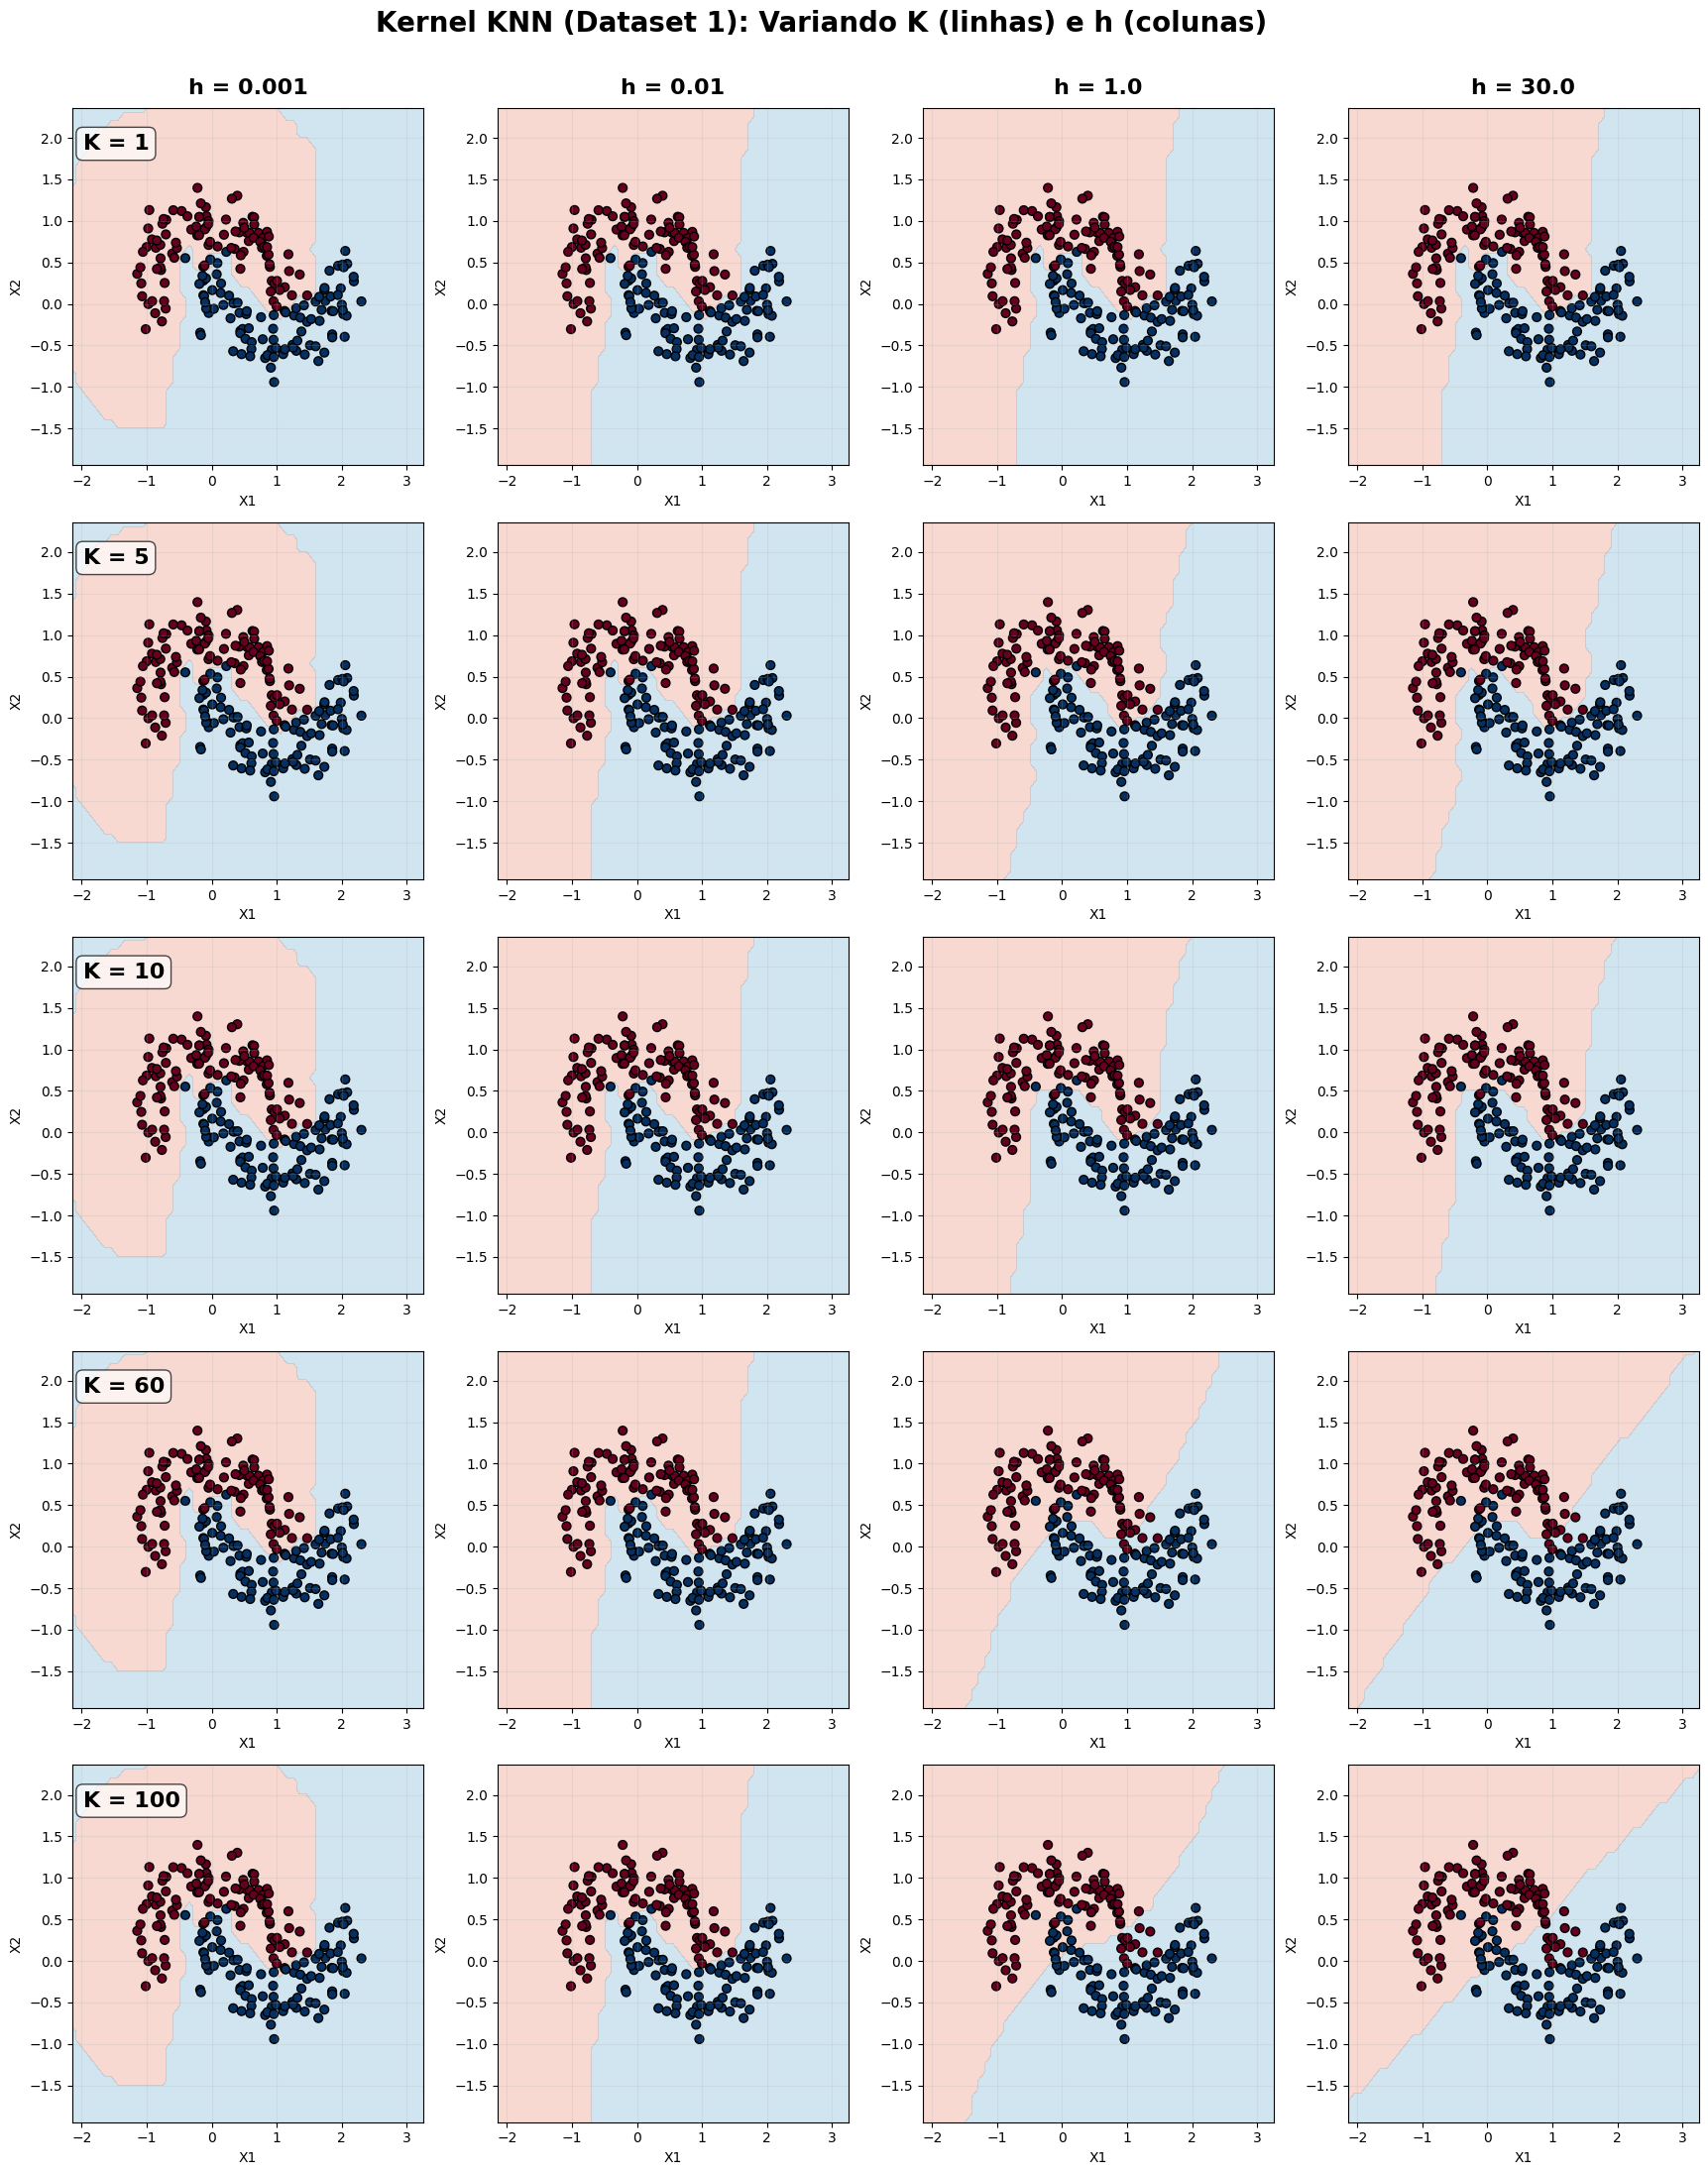

In [72]:
# Valores de K e de h a serem testados
k_values = [1, 5, 10, 60, 100]
h_values = [0.001, 0.01, 1.0, 30.0]

# Usar apenas o PRIMEIRO conjunto de dados criado
X, y, label = datasets_list[1]

# Criar figura com grid 5x4 (5 K's na vertical, 4 h's na horizontal)
fig, axes = plt.subplots(5, 4, figsize=(18, 22))
fig.suptitle(f'Kernel KNN (Dataset 1): Variando K (linhas) e h (colunas)', 
             fontsize=20, fontweight='bold', y=0.995)

# Para cada linha (K) e coluna (h)
for row, k in enumerate(k_values):
    for col, h in enumerate(h_values):
        ax = axes[row, col]
        
        # Criar o grid de pontos
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
                             np.arange(y_min, y_max, 0.1))
        
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Classificar cada ponto do grid usando mykernel_knn
        Z = np.array([mykernel_knn(xi_yi, X, y, h, k) for xi_yi in grid_points])
        
        # Tratar empates (0.0 virando 1.0) para não corromper o contorno
        Z[Z == 0.0] = 1.0 
        Z = Z.reshape(xx.shape)
        
        # Plotar
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=1)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', s=40)
        
        # Títulos
        if col == 0:
            ax.text(0.03, 0.9, f'K = {k}', transform=ax.transAxes,
                   fontsize=16, fontweight='bold', color='black',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
                   verticalalignment='center', rotation=0)
            
        if row == 0:
            ax.set_title(f'h = {h}', fontsize=16, fontweight='bold', pad=10)
        
        ax.set_xlabel('X1', fontsize=10)
        ax.set_ylabel('X2', fontsize=10)
        ax.grid(alpha=0.2)

plt.tight_layout()
# Ajuste de layout manual pra acomodar o text do K e título
plt.subplots_adjust(left=0.08, top=0.95)
plt.show()

## Discussão

Nessa abordagem, o equilíbrio entre viés e variância é determinado pela interação entre $k$ (tamanho da vizinhança) e $h$ (largura de banda do kernel). Enquanto $k$ define quantos pontos participam da decisão, $h$ determina o peso desses pontos em função da distância: um $h$ pequeno faz com que a influência decaia rapidamente, aproximando o modelo de um caso efetivo de $k = 1$ (alta variância e possível overfitting). Por outro lado, um $h$ grande suaviza a fronteira de decisão, tornando-a semelhante a uma média ponderada mais uniforme (alto viés).

No entanto, observa-se que, ao fixar $k = 1$, a variação de $h$ não é suficiente para suavizar a fronteira de decisão: mesmo com $h$ grande, o modelo mantém alta variância. De forma análoga, ao fixar $h$ pequeno, o aumento de $k$ não elimina completamente a irregularidade da fronteira.

Para obter uma fronteira com alto viés e baixa variância, é necessário aumentar simultaneamente $h$ e $k$. Assim, a escolha ideal dos parâmetros corresponde a um equilíbrio entre esses dois efeitos, buscando minimizar o erro de generalização.

##  Exercício de Fixação 1.3

Efetuando as execuções com breast_cancer
Concluído! Melhor K médio: 7 com acurácia de 0.9684


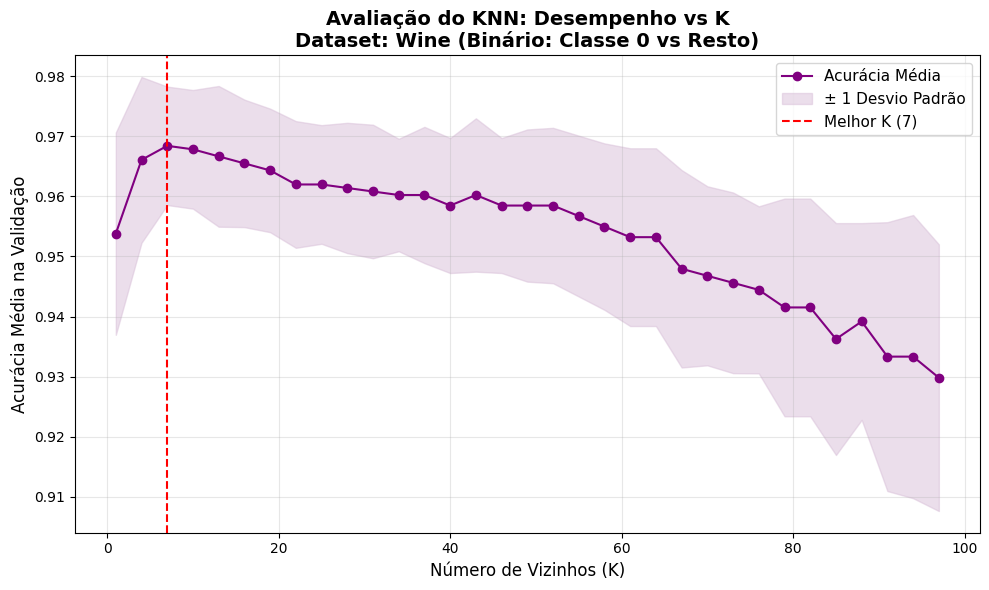

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

X_real = data.data
y_real = data.target

y_real = np.where(y_real == 0, 1, -1)

n_runs = 10

k_values_real = list(range(1, 100, 3)) 

mean_accs = []
std_accs = []

print("Efetuando as execuções com breast_cancer")

# 3. Laço principal variando k e executando n_runs vezes
for k_val in k_values_real:
    acc_k = []
    
    # As 10 repetições para o mesmo k
    for run in range(n_runs):
        # Separação aleatória 70% Treino e 30% Validação 
        # (usamos 'run' como random_state para os mesmos cortes a cada k)
        X_train, X_val, y_train, y_val = train_test_split(
            X_real, y_real, test_size=0.3, random_state=run+1
        )
        
        # NORMALIZAÇÃO: Fundamental para KNN em dados reais 
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Predição e acurácia usando a myknn (que suporta classes -1 e 1)
        y_pred = [myknn(xv, X_train_scaled, y_train, k_val) for xv in X_val_scaled]
        acc = np.mean(y_pred == y_val)
        acc_k.append(acc)
        
    mean_accs.append(np.mean(acc_k))
    std_accs.append(np.std(acc_k))

mean_accs = np.array(mean_accs)
std_accs = np.array(std_accs)

# Calcular melhor K da simulação
best_idx = np.argmax(mean_accs)
best_k = k_values_real[best_idx]
best_acc = mean_accs[best_idx]
print(f"Concluído! Melhor K médio: {best_k} com acurácia de {best_acc:.4f}")

# 4. Gerar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_values_real, mean_accs, marker='o', linestyle='-', color='purple', label='Acurácia Média')

# Área sombreada do desvio padrão
plt.fill_between(k_values_real, mean_accs - std_accs, mean_accs + std_accs, 
                 color='thistle', alpha=0.5, label='± 1 Desvio Padrão')

plt.axvline(best_k, color='red', linestyle='--', label=f'Melhor K ({best_k})')

plt.title('Avaliação do KNN: Desempenho vs K\nDataset: Wine (Binário: Classe 0 vs Resto)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Número de Vizinhos (K)', fontsize=12)
plt.ylabel('Acurácia Média na Validação', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Discussão

No exemplo apresentado, observa-se que, a partir de um determinado valor de $k$, a acurácia média tende a diminuir, enquanto a variância da acurácia aumenta. Esse comportamento sugere que, para valores pequenos de $k$, o modelo apresenta overfitting (alta variância), enquanto, para valores grandes de $k$, ocorre underfitting (alto viés).

Uma abordagem ingênua seria selecionar o valor de $k$ que maximiza a acurácia média. No entanto, esse procedimento pode introduzir viés na avaliação do modelo, uma vez que o mesmo conjunto de dados estaria sendo utilizado tanto para ajuste quanto para avaliação.

Dessa forma, a prática recomendada é dividir o conjunto de dados em três subconjuntos: treino, validação e teste. O hiperparâmetro $k$ deve ser escolhido com base no desempenho no conjunto de validação, enquanto o conjunto de teste deve ser utilizado apenas para a avaliação final do modelo, fornecendo uma estimativa mais imparcial de sua capacidade de generalização.

##  Exercício de Fixação 1.4

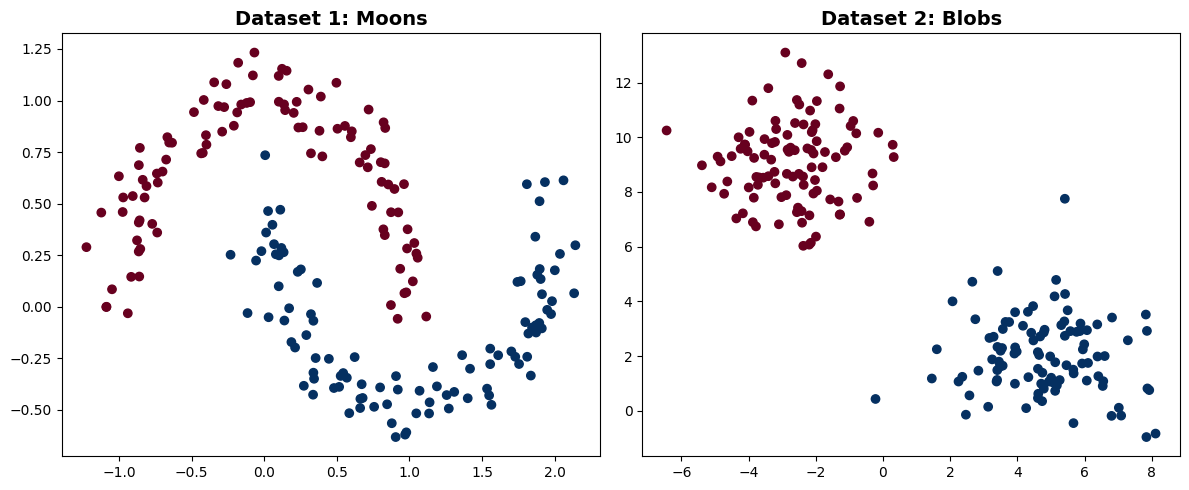

In [77]:
X1,y1 = datasets.make_moons(n_samples=200, noise=0.1, random_state=42)
y1 = np.where(y1 == 0, -1, 1) # Converter

X2,y2 = datasets.make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=42)
y2 = np.where(y2 == 0, -1, 1) # <--- ESSA LINHA FALTAVA PARA CONVERTER O BLOBS TBM

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X1[:, 0], X1[:, 1], c=y1, cmap='RdBu')
plt.title('Dataset 1: Moons', fontsize=14, fontweight='bold')
plt.subplot(1, 2, 2)
plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='RdBu')
plt.title('Dataset 2: Blobs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

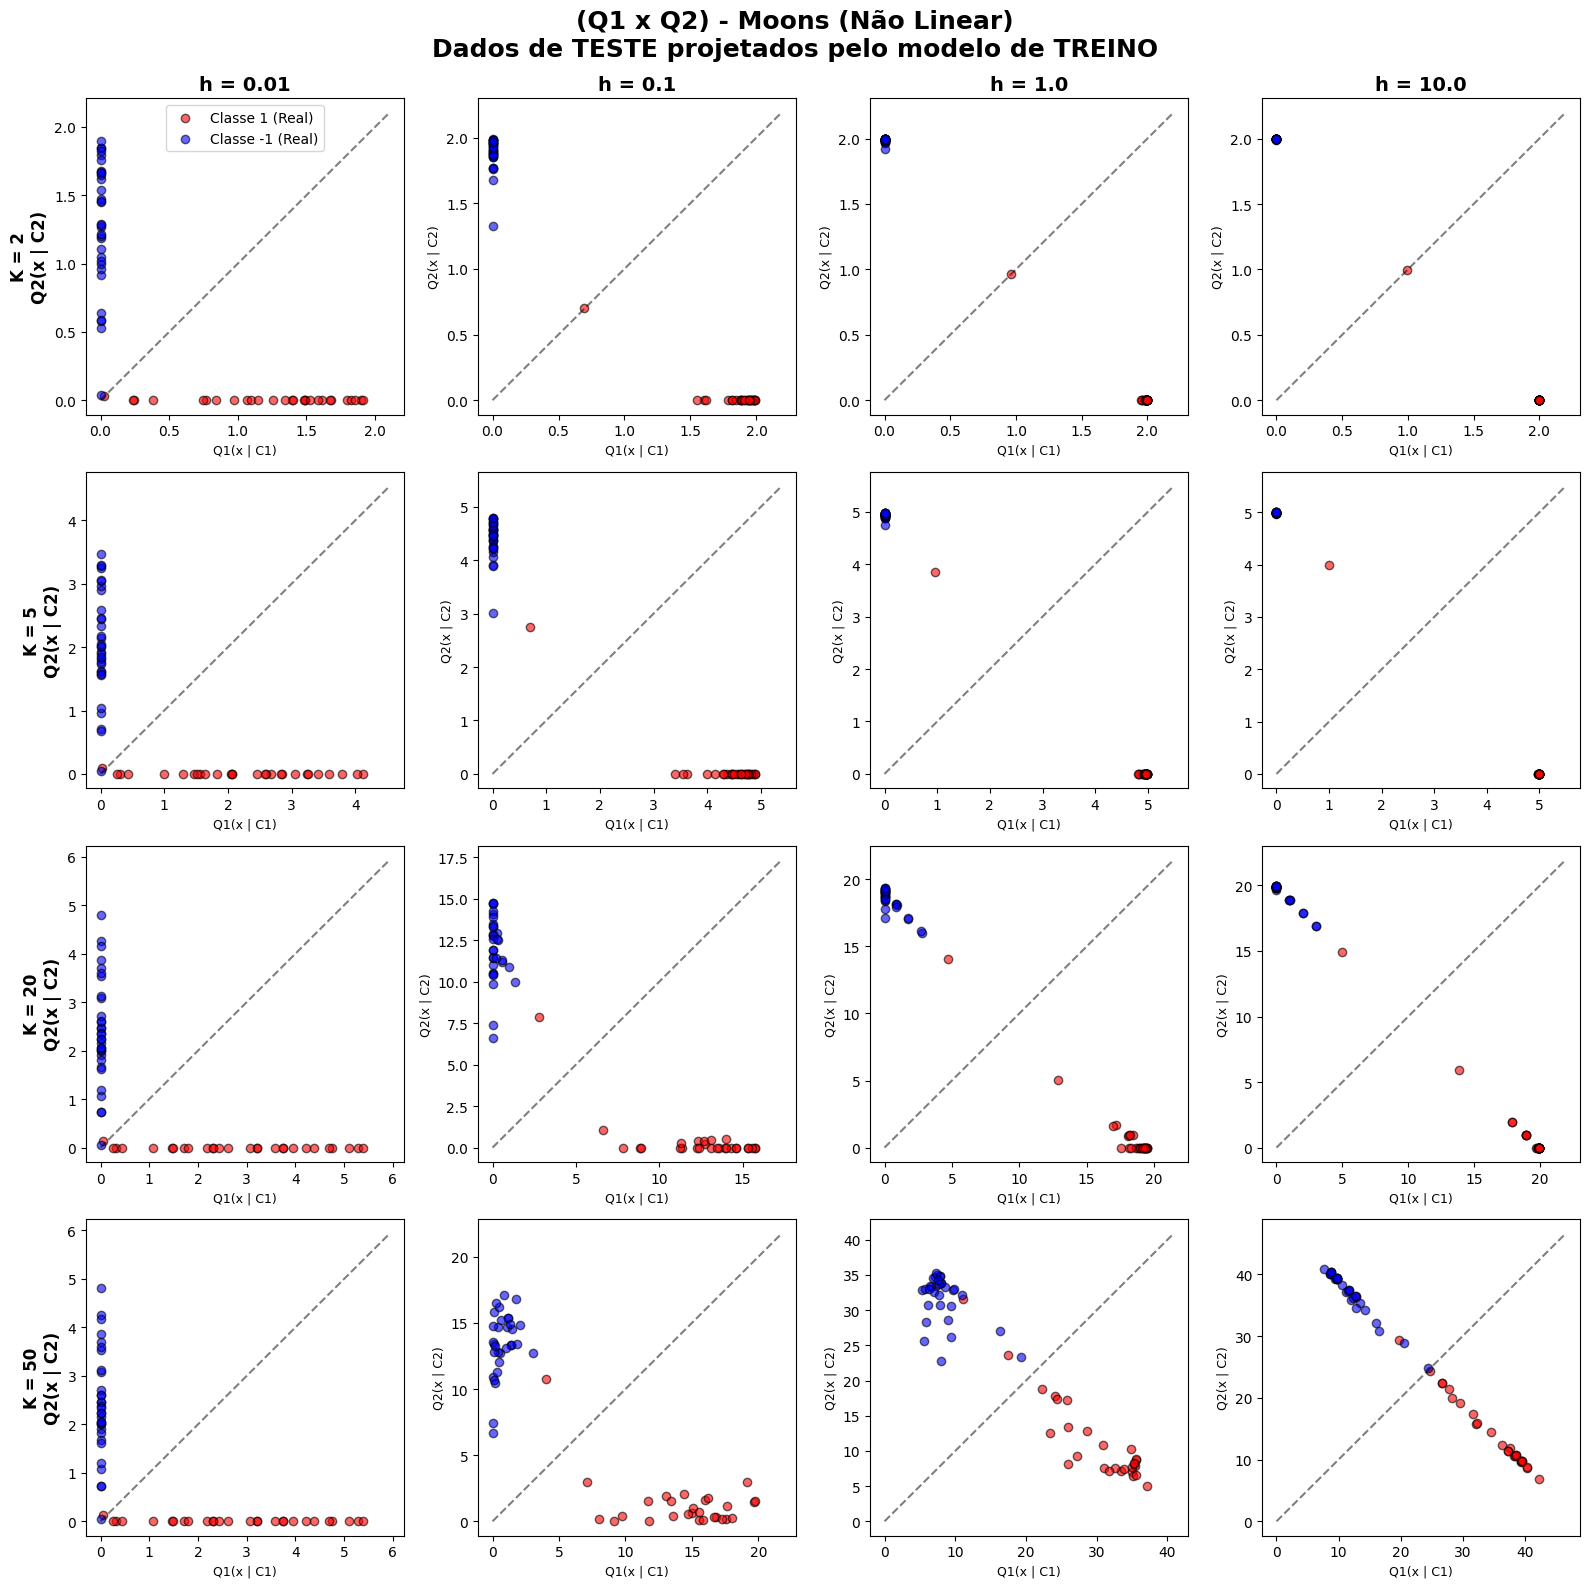

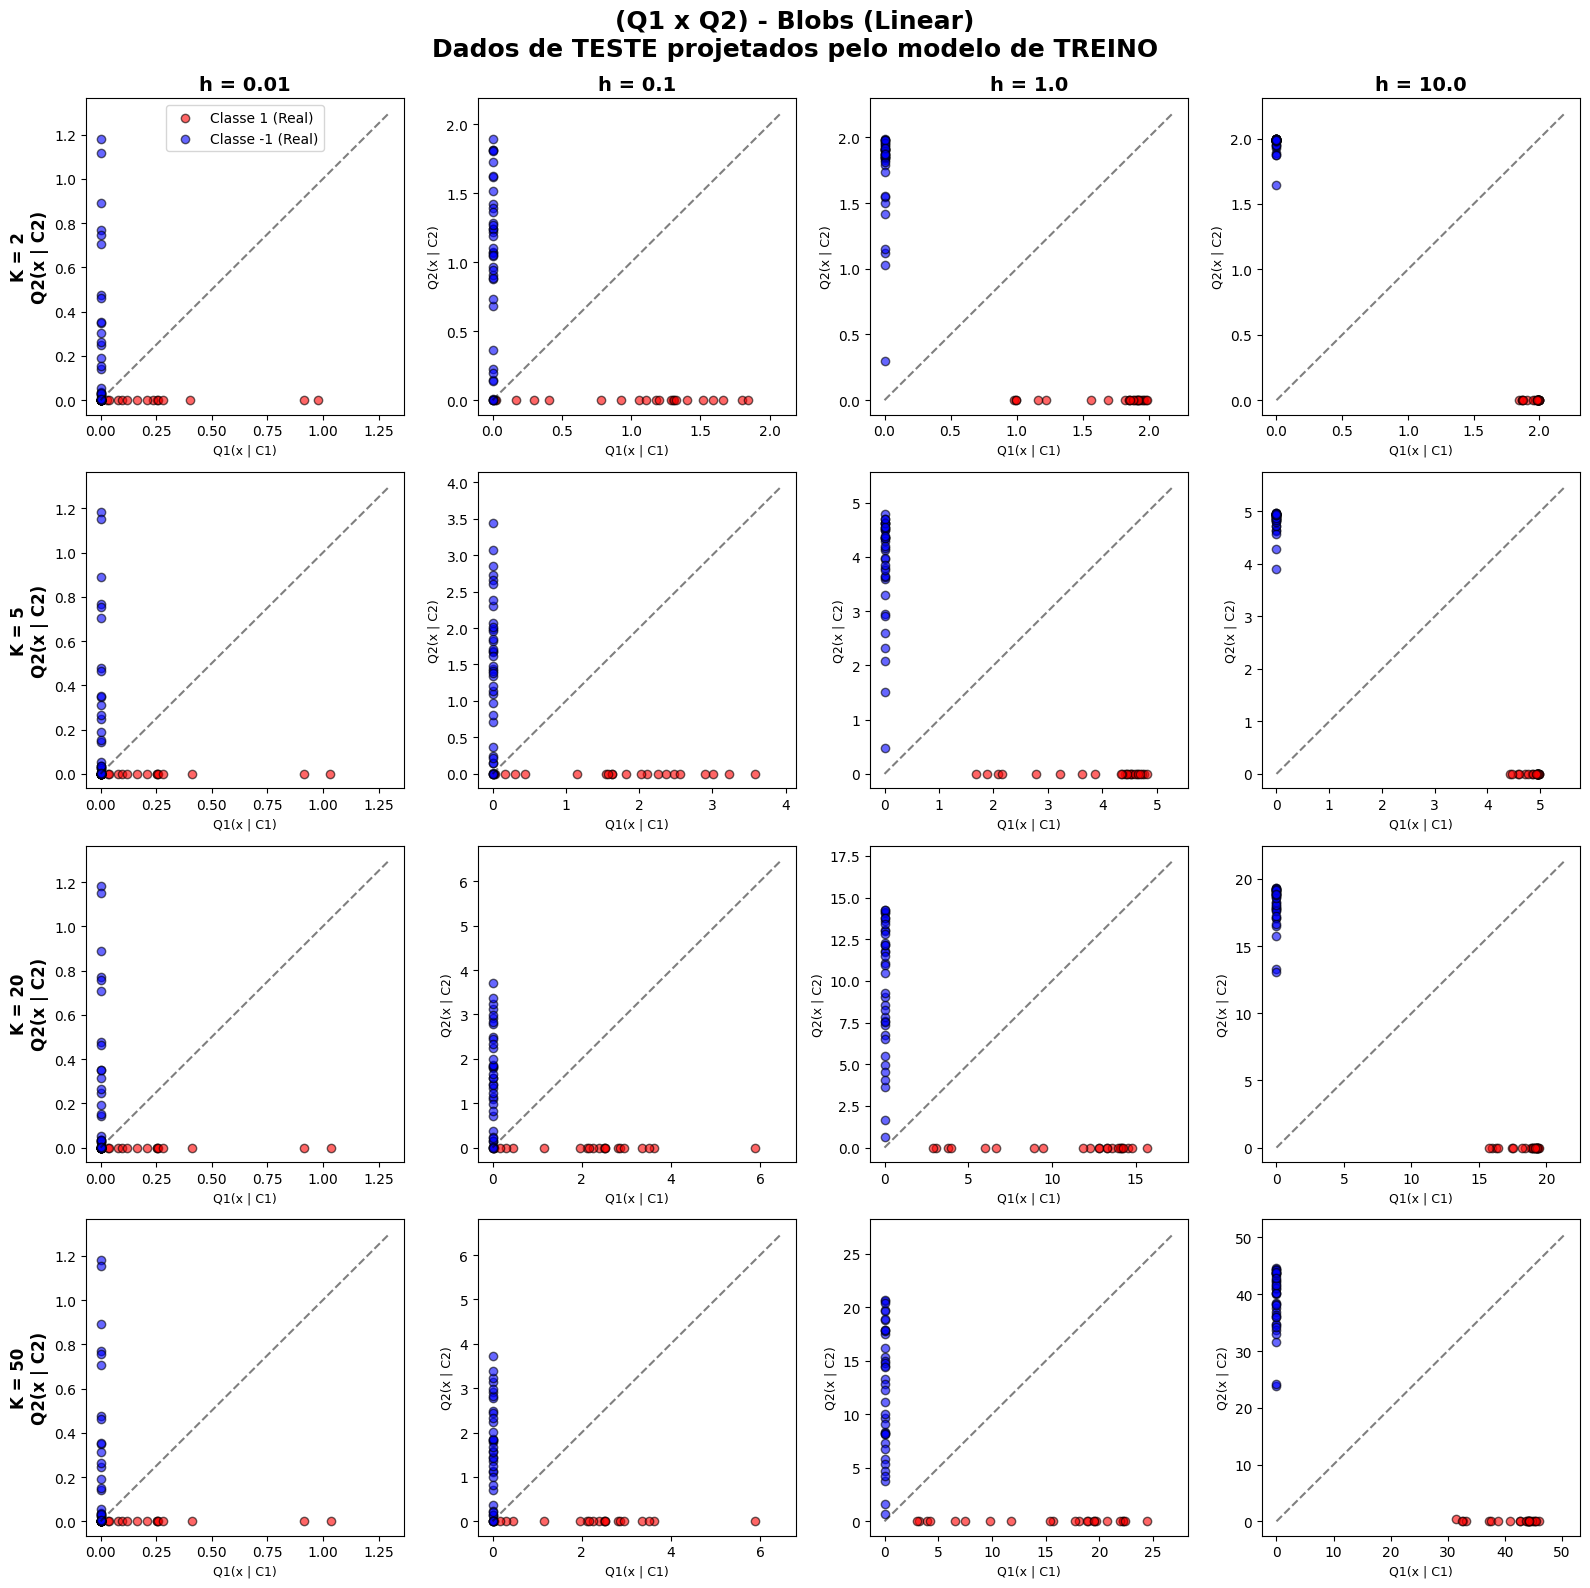

In [ ]:
from sklearn.model_selection import train_test_split

def q_values_knn(xt, xall, yall, h, k):
    """
    Retorna as parcelas Q1(x|C1) [classe 1] e Q2(x|C2) [classe -1]
    para as amostras xt dadas, utilizando xall e yall como base de vizinhos.
    """
    Q1_list = []
    Q2_list = []
    
    if xt.ndim == 1:
        xt = xt.reshape(1, -1)
        
    for x_i in xt:
        dist = np.sum((xall - x_i)**2, axis=1) 
        idx = np.argsort(dist)[:k] 
        
        pesos = np.exp(-0.5 * dist[idx] / h)
        labels_vizinhos = yall[idx]
        
        q1 = np.sum(pesos[labels_vizinhos == 1])
        q2 = np.sum(pesos[labels_vizinhos == -1])
        
        Q1_list.append(q1)
        Q2_list.append(q2)
        
    return np.array(Q1_list), np.array(Q2_list)

k_values = [1, 5, 20, 50]
h_values = [0.01, 0.1, 1.0, 10.0]

datasets_test = [("Moons (Não Linear)", X1, y1), ("Blobs (Linear)", X2, y2)]

for nome_ds, X_ds, y_ds in datasets_test:
    # Divisão em treino e teste para que um ponto não influencie a si mesmo
    X_train, X_test, y_train, y_test = train_test_split(X_ds, y_ds, test_size=0.3, random_state=42)
    
    fig, axes = plt.subplots(len(k_values), len(h_values), figsize=(16, 16))
    fig.suptitle(f"(Q1 x Q2) - {nome_ds}\nDados de TESTE projetados pelo modelo de TREINO", 
                 fontsize=18, fontweight='bold', y=0.99)
    
    for row, k in enumerate(k_values):
        for col, h in enumerate(h_values):
            ax = axes[row, col]
            
            # Projetar apenas as amostras de TESTE usando o TREINO como referência
            Q1_vals, Q2_vals = q_values_knn(X_test, X_train, y_train, h, k)
            
            # Plotar as projeções (X_test colorido pelo y_test real)
            ax.scatter(Q1_vals[y_test==1], Q2_vals[y_test==1], c='red', label='Classe 1 (Real)', alpha=0.6, edgecolors='k')
            ax.scatter(Q1_vals[y_test==-1], Q2_vals[y_test==-1], c='blue', label='Classe -1 (Real)', alpha=0.6, edgecolors='k')
            
            # Reta de Separação (Q1 = Q2)
            max_val = max(np.max(Q1_vals), np.max(Q2_vals))
            if max_val == 0: max_val = 1
            ax.plot([0, max_val*1.1], [0, max_val*1.1], 'k--', alpha=0.5)
            
            if col == 0:
                ax.set_ylabel(f"K = {k}\nQ2(x | C2)", fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel("Q2(x | C2)", fontsize=9)
                
            if row == 0:
                ax.set_title(f"h = {h}", fontsize=14, fontweight='bold')
                
            ax.set_xlabel("Q1(x | C1)", fontsize=9)
            
            if row == 0 and col == 0:
                ax.legend(loc='best')
                
    plt.tight_layout()
    plt.show()